## Вариант 2 - зона F2_Z2_****

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Ellipse, Polygon, Arc
from sklearn.preprocessing import MinMaxScaler

## 1. Загрузка и первичный анализ данных

In [12]:
df = pd.read_csv('bldg-MC2.csv')

# Преобразуем столбец с датой/временем в формат datetime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])
# Создаём отдельный столбец с датой без времени для группировки
df['Date'] = df['Date/Time'].dt.date

print("Строк:", len(df))
print("Период данных: ", df['Date'].min(), "-", df['Date'].max())
print("Всего дней в датасете:", df['Date'].nunique())

Строк: 4032
Период данных:  2016-05-31 - 2016-06-13
Всего дней в датасете: 14


## 2. Отбор параметров для варианта 2 (F2_Z2)

In [13]:
# Выбираем все столбцы, содержащие 'F_2_Z_2' – это параметры нашей зоны
zone_cols = [col for col in df.columns if 'F_2_Z_2' in col]
print(f"Найдено признаков для варианта 2 (F2_Z2): {len(zone_cols)}")
print("Список признаков:")
for i, col in enumerate(zone_cols, 1):
    print(f"{i:2d}. {col}")

drybulb_col = next((col for col in df.columns if 'Drybulb' in col), None)
if drybulb_col is None:
    raise KeyError("Столбец с внешней температурой не найден")

# Функция для поиска нужного столбца по ключевому слову
def find_col(keyword):
    for col in zone_cols:
        if keyword in col:
            return col
    raise KeyError(f"Столбец, содержащий '{keyword}', не найден")

# Извлекаем конкретные столбцы по ключевым словам
lights_col   = find_col('Lights Power')
equip_col    = find_col('Equipment Power')
temp_col     = find_col('Thermostat Temp')
damper_col   = find_col('Damper Position')
reheat_col   = find_col('REHEAT COIL Power')
co2_col      = find_col('CO2 Concentration')
supply_temp_col = find_col('SUPPLY INLET Temperature')
supply_flow_col = find_col('SUPPLY INLET Mass Flow Rate')

# Формируем список отобранных столбцов (включая внешнюю температуру)
selected_cols = [
    drybulb_col,
    lights_col,
    equip_col,
    temp_col,
    damper_col,
    reheat_col,
    co2_col,
    supply_temp_col,
    supply_flow_col
]

# Словарь для коротких названий (для удобства отображения)
short_names = {
    drybulb_col: 'Outdoor Temp',
    lights_col: 'Light Power',
    equip_col: 'Equip Power',
    temp_col: 'Room Temp',
    damper_col: 'Damper Pos',
    reheat_col: 'Reheat Power',
    co2_col: 'CO2',
    supply_temp_col: 'Supply Temp',
    supply_flow_col: 'Supply Flow'
}

print("Отобрано параметров:", len(selected_cols))
for col in selected_cols:
    print(f"  {col} -> {short_names[col]}")

# Выводим информацию о типах данных и статистику
print(df[selected_cols].info())

print("Статистическое описание:")
print(df[selected_cols].describe().round(3))

print("Анализ разброса значений:")
for col in selected_cols:
    minv, maxv = df[col].min(), df[col].max()
    ratio = maxv / (minv if minv != 0 else 1)
    print(f"{short_names[col]:<20} | мин:{minv:10.2f} | макс:{maxv:10.2f} | отношение:{ratio:10.2f}")

Найдено признаков для варианта 2 (F2_Z2): 10
Список признаков:
 1.  F_2_Z_2: Lights Power
 2.  F_2_Z_2: Equipment Power
 3.  F_2_Z_2: Thermostat Temp
 4.  F_2_Z_2: Thermostat Heating Setpoint
 5.  F_2_Z_2: Thermostat Cooling Setpoint
 6.  F_2_Z_2 VAV REHEAT Damper Position
 7.  F_2_Z_2 REHEAT COIL Power
 8.  F_2_Z_2 RETURN OUTLET CO2 Concentration
 9.  F_2_Z_2 SUPPLY INLET Temperature
10.  F_2_Z_2 SUPPLY INLET Mass Flow Rate
Отобрано параметров: 9
   Drybulb Temperature -> Outdoor Temp
   F_2_Z_2: Lights Power -> Light Power
   F_2_Z_2: Equipment Power -> Equip Power
   F_2_Z_2: Thermostat Temp -> Room Temp
   F_2_Z_2 VAV REHEAT Damper Position -> Damper Pos
   F_2_Z_2 REHEAT COIL Power -> Reheat Power
   F_2_Z_2 RETURN OUTLET CO2 Concentration -> CO2
   F_2_Z_2 SUPPLY INLET Temperature -> Supply Temp
   F_2_Z_2 SUPPLY INLET Mass Flow Rate -> Supply Flow
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 9 columns):
 #   Column                

## 3. Корреляционный анализ

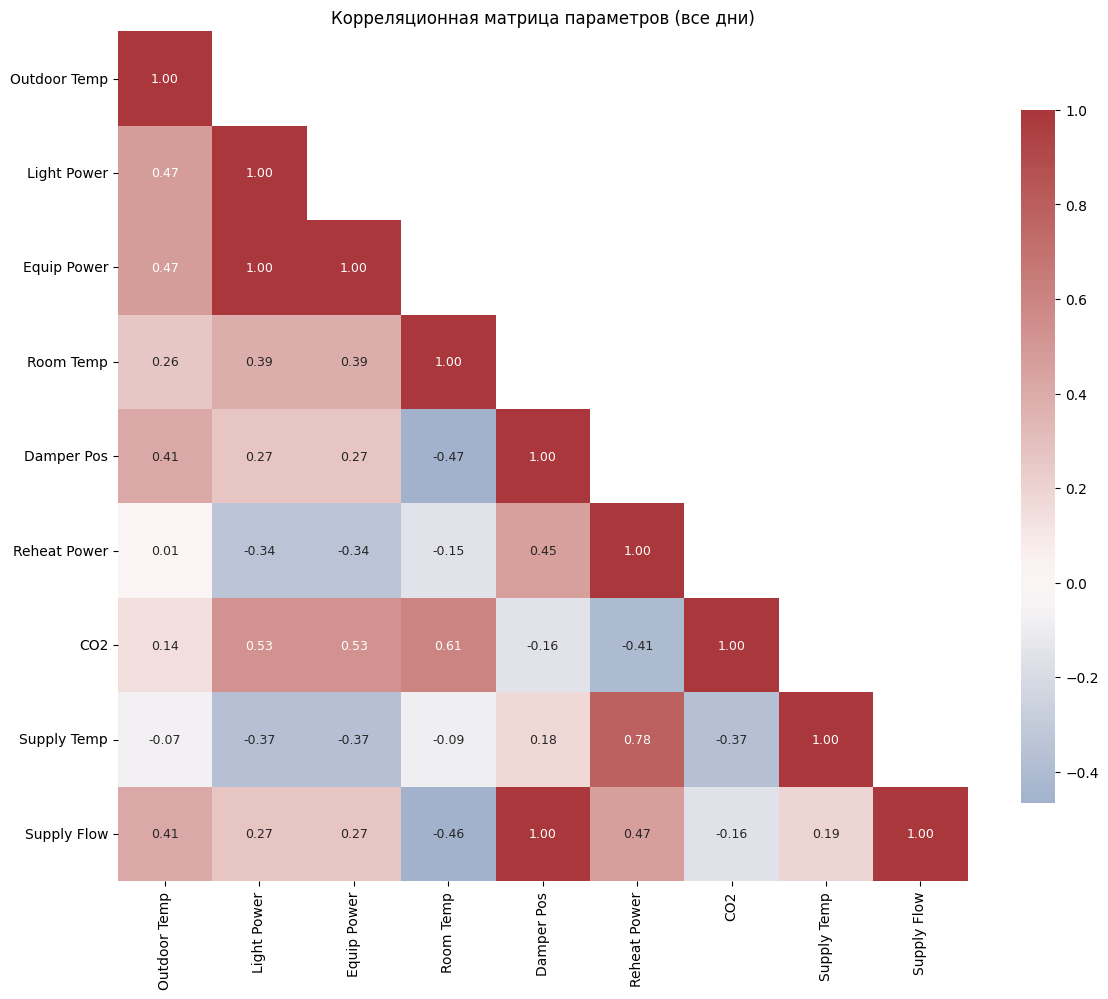

Основные корреляции (|r| > 0.7):
  Light Power          - Equip Power          : 1.000
  Damper Pos           - Supply Flow          : 0.998
  Reheat Power         - Supply Temp          : 0.785


In [14]:
# Вычисляем корреляционную матрицу для выбранных столбцов
corr_matrix = df[selected_cols].corr()
# Получаем короткие названия для подписей осей
labels = [short_names[c] for c in selected_cols]

plt.figure(figsize=(12, 10))
# Создаём маску для верхнего треугольника (чтобы не дублировать значения)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    data=corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
plt.title('Корреляционная матрица параметров (все дни)')
plt.tight_layout()
plt.savefig('corr_matrix_var2.png', dpi=150)
plt.show()

# Выводим пары с высокой корреляцией
print("Основные корреляции (|r| > 0.7):")
for i in range(len(selected_cols)):
    for j in range(i+1, len(selected_cols)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {labels[i]:<20} - {labels[j]:<20} : {val:.3f}")

## 4. Агрегация по дням и нормализация

In [15]:
# Группируем данные по дате и вычисляем средние значения за день
daily = df.groupby('Date')[selected_cols].mean()
# Переименовываем столбцы в короткие названия
daily.columns = [short_names[c] for c in daily.columns]

print("Среднесуточные значения (первые 5 дней):")
print(daily.head().round(3))

# Инициализируем нормализатор для приведения значений к диапазону [0, 1]
scaler = MinMaxScaler()
# Применяем нормализацию
daily_norm = pd.DataFrame(
    data=scaler.fit_transform(daily),
    index=daily.index,
    columns=daily.columns
)

print("Нормализованные среднесуточные значения (первые 5 дней):")
print(daily_norm.head().round(3))

Среднесуточные значения (первые 5 дней):
            Outdoor Temp  Light Power  Equip Power  Room Temp  Damper Pos  \
Date                                                                        
2016-05-31        24.658     1402.601     1130.291     23.981       0.548   
2016-06-01        24.772     1436.811     1149.449     24.067       0.564   
2016-06-02        25.305     1445.364     1154.238     24.190       0.583   
2016-06-03        25.290     1394.049     1125.502     24.232       0.588   
2016-06-04        25.672        0.000      344.835     24.295       0.292   

            Reheat Power       CO2  Supply Temp  Supply Flow  
Date                                                          
2016-05-31           0.0  1025.190       13.164        0.290  
2016-06-01           0.0  1030.090       13.173        0.298  
2016-06-02           0.0  1008.062       13.188        0.308  
2016-06-03           0.0  1002.620       13.186        0.311  
2016-06-04           0.0   667.270       

## 5. Схема кодирования для лиц Чернова
<br>Левая бровь  : Damper Pos
<br>Правая бровь : Supply Flow
<br>Левый глаз    : Light Power
<br>Правый глаз   : Equip Power
<br>Нос           : CO2
<br>Рот           : Reheat Power
<br>Цвет лица     : Room Temp
<br>Цвет волос    : Supply Temp
<br>Длина волос   : Outdoor Temp
<br>(симметричные черты для коррелирующих пар)

In [16]:
# Функция для извлечения параметров лица из строки данных
def extract_face_params(row):
    return {
        'left_brow'   : row['Damper Pos'],
        'right_brow'  : row['Supply Flow'],
        'left_eye'    : row['Light Power'],
        'right_eye'   : row['Equip Power'],
        'nose'        : row['CO2'],
        'mouth'       : row['Reheat Power'],
        'skin_color'  : row['Room Temp'],
        'hair_color'  : row['Supply Temp'],
        'hair_length' : row['Outdoor Temp']
    }

# Цветовая карта для температуры (холодный -> тёплый)
temp_cmap = plt.cm.coolwarm

# Функция рисования одного лица Чернова на заданных осях
def draw_chernoff_face(ax, params, face_scale=1.0):
    ax.clear()
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')

    # Параметры лица (ширина, высота, центр)
    w_face = 1.5 * face_scale
    h_face = 1.7 * face_scale
    center = (0, 0)
    u = w_face / 7

    # Волосы (цвет и длина)
    hair_width = 1.7 * face_scale
    hair_top_y = 0.5 * face_scale
    hair_radius = 0.5 * face_scale
    hair_bottom = hair_top_y - hair_radius - (1 - params['hair_length']) * 1.2 * face_scale
    hair_color = temp_cmap(params['hair_color'])

    hair_rect = Polygon(
        [   (-hair_width/2, hair_bottom),
            (hair_width/2, hair_bottom),
            (hair_width/2, hair_top_y),
            (-hair_width/2, hair_top_y) ],
        closed=True,
        fc=hair_color,
        ec='none',
        zorder=0
    )
    ax.add_patch(hair_rect)

    hair_ellipse = Ellipse(
        (0, hair_top_y),
        width=hair_width,
        height=2*hair_radius,
        fc=hair_color,
        ec='none',
        zorder=0
    )
    ax.add_patch(hair_ellipse)

    # Лицо (овал с цветом кожи)
    skin_color = temp_cmap(params['skin_color'])
    face_oval = Ellipse(
        center,
        width=w_face,
        height=h_face,
        fc=skin_color,
        ec='black',
        linewidth=1,
        zorder=1
    )
    ax.add_patch(face_oval)

    # Глаза (размер зависит от мощности оборудования/освещения)
    eye_x_offset = u * 1.5
    eye_y = u / 2
    eye_width = u * 1.5
    eye_height_left = max(u * params['left_eye'], 0.05)
    eye_height_right = max(u * params['right_eye'], 0.05)

    left_eye = Ellipse(
        (-eye_x_offset, eye_y),
        width=eye_width,
        height=eye_height_left,
        fc='white',
        ec='black',
        linewidth=1,
        zorder=2
    )
    ax.add_patch(left_eye)
    left_pupil = Ellipse(
        (-eye_x_offset, eye_y),
        width=eye_width/2,
        height=eye_height_left/2,
        fc='black',
        ec='black',
        linewidth=1,
        zorder=3
    )
    ax.add_patch(left_pupil)

    right_eye = Ellipse(
        (eye_x_offset, eye_y),
        width=eye_width,
        height=eye_height_right,
        fc='white',
        ec='black',
        linewidth=1,
        zorder=2
    )
    ax.add_patch(right_eye)
    right_pupil = Ellipse(
        (eye_x_offset, eye_y),
        width=eye_width/2,
        height=eye_height_right/2,
        fc='black',
        ec='black',
        linewidth=1,
        zorder=3
    )
    ax.add_patch(right_pupil)

    # Брови (изогнутость зависит от положения заслонки и расхода)
    brow_y = eye_y + u * 1.1
    brow_width = u * 1.5
    brow_height_left = max(u * params['left_brow'], 0.001)
    brow_height_right = max(u * params['right_brow'], 0.001)

    left_brow = Arc(
        (-eye_x_offset, brow_y),
        width=brow_width,
        height=brow_height_left,
        theta1=0,
        theta2=180,
        edgecolor='black',
        lw=2,
        zorder=4
    )
    ax.add_patch(left_brow)

    right_brow = Arc(
        (eye_x_offset, brow_y),
        width=brow_width,
        height=brow_height_right,
        theta1=0,
        theta2=180,
        edgecolor='black',
        lw=2,
        zorder=4
    )
    ax.add_patch(right_brow)

    # Нос (треугольник, размер зависит от CO2)
    nose_width = u * params['nose']
    nose_height = u
    nose_tip = (0, 0)
    nose_left = (-nose_width/2, -nose_height)
    nose_right = (nose_width/2, -nose_height)
    nose_triangle = Polygon(
        [nose_left, nose_right, nose_tip],
        closed=True,
        fc='peru',
        ec='black',
        lw=1,
        zorder=2
    )
    ax.add_patch(nose_triangle)

    # Рот (эллипс, ширина зависит от мощности рекуперации)
    mouth_center = (0, -u * 2)
    mouth_width = u * 3 * params['mouth']
    mouth_height = u * 0.3
    mouth = Ellipse(
        mouth_center,
        width=mouth_width,
        height=mouth_height,
        fc='black',
        ec='black',
        lw=1,
        zorder=2
    )
    ax.add_patch(mouth)

## 6. Эталонные лица для проверки визуального восприятия

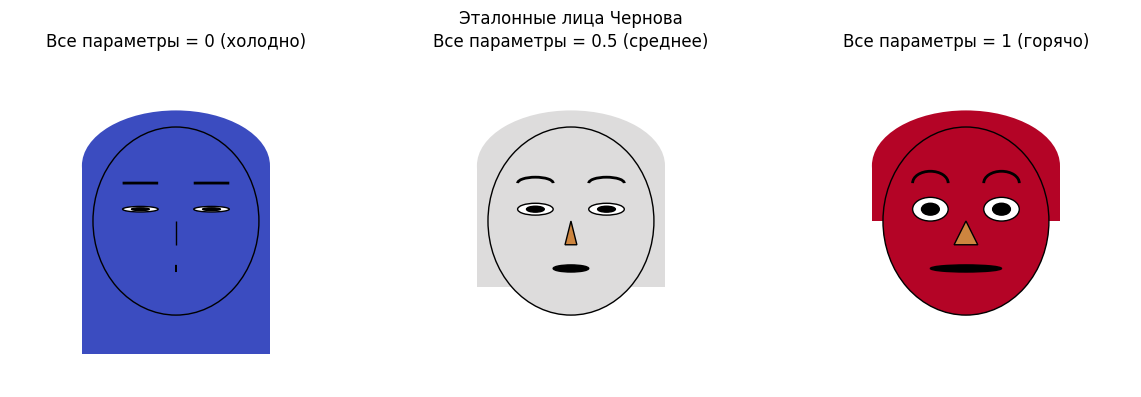

In [17]:
# Создаём три эталонных набора параметров: все минимумы, средние, максимумы
ref_cold = {k: 0.0 for k in ['left_brow','right_brow','left_eye','right_eye','nose','mouth','skin_color','hair_color','hair_length']}
ref_mid  = {k: 0.5 for k in ref_cold}
ref_hot  = {k: 1.0 for k in ref_cold}

# Рисуем эталонные лица для наглядности
fig_ref, axes_ref = plt.subplots(1, 3, figsize=(12, 4))
draw_chernoff_face(axes_ref[0], ref_cold)
axes_ref[0].set_title('Все параметры = 0 (холодно)')
draw_chernoff_face(axes_ref[1], ref_mid)
axes_ref[1].set_title('Все параметры = 0.5 (среднее)')
draw_chernoff_face(axes_ref[2], ref_hot)
axes_ref[2].set_title('Все параметры = 1 (горячо)')
plt.suptitle('Эталонные лица Чернова')
plt.tight_layout()
plt.savefig('chernoff_reference_var2.png', dpi=150)
plt.show()

## 7. Построение лиц для каждого дня

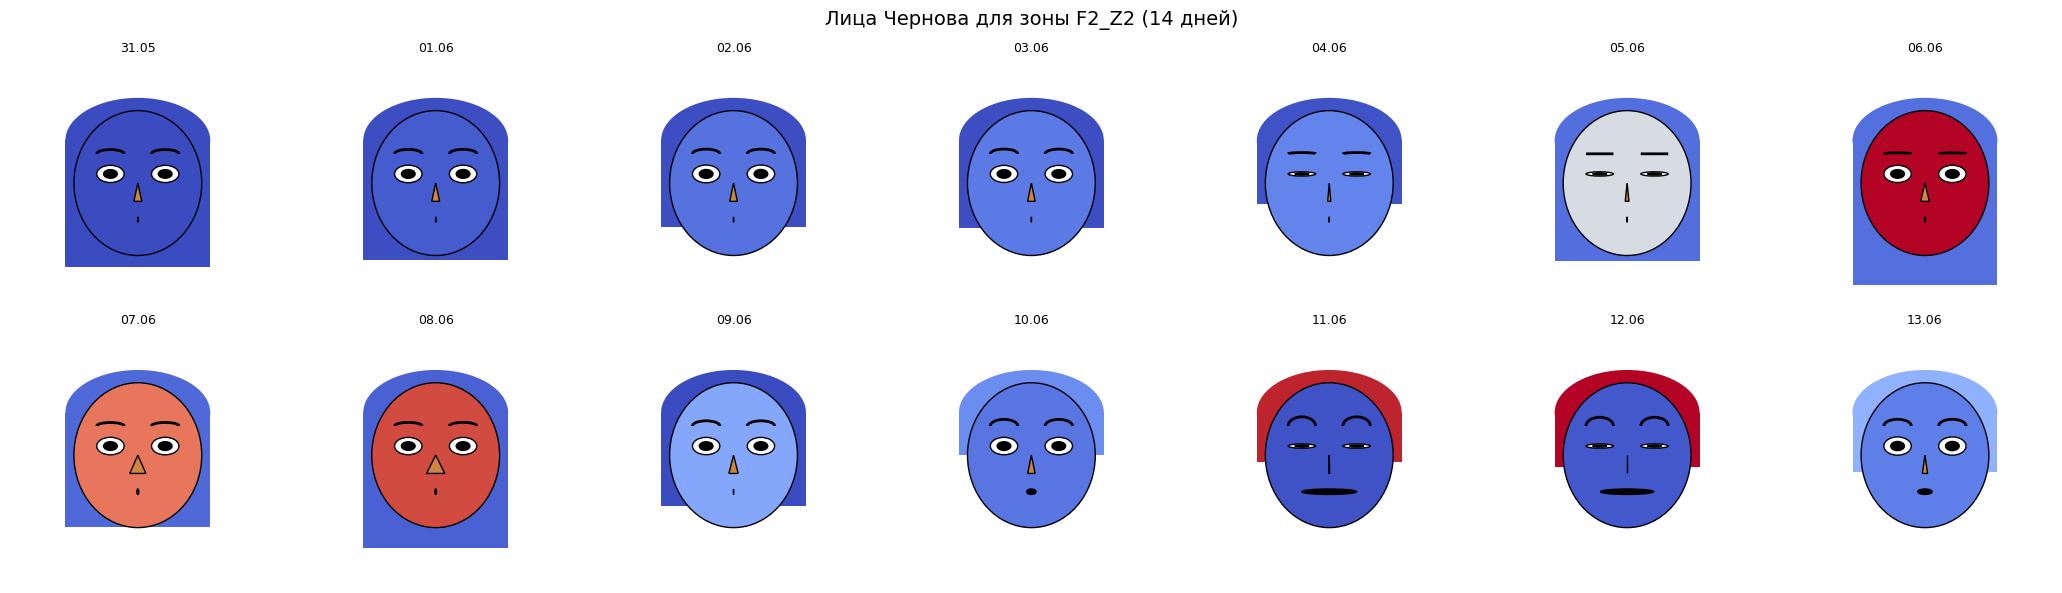

In [18]:
dates = sorted(daily_norm.index)
n_days = len(dates)
cols = 7
rows = (n_days + cols - 1) // cols  # вычисляем количество строк для сетки

fig_days, axes_days = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
axes_days = axes_days.flatten()

for idx, date in enumerate(dates):
    row = daily_norm.loc[date]
    params = extract_face_params(row)
    draw_chernoff_face(axes_days[idx], params)
    axes_days[idx].set_title(date.strftime('%d.%m'), fontsize=9, pad=2)

# Скрываем лишние оси (если дней меньше, чем ячеек в сетке)
for j in range(idx+1, len(axes_days)):
    axes_days[j].axis('off')

plt.suptitle('Лица Чернова для зоны F2_Z2 (14 дней)', fontsize=14)
plt.tight_layout()
plt.savefig('chernoff_daily_var2.png', dpi=150)
plt.show()

## 8. Поиск аномалий (отклонение от среднего лица)

Средние нормализованные значения (базовое лицо):
  Light Power     : 0.683
  Equip Power     : 0.683
  Room Temp       : 0.291
  Damper Pos      : 0.499
  Supply Flow     : 0.500
  CO2             : 0.405
  Reheat Power    : 0.178
  Supply Temp     : 0.193
  Outdoor Temp    : 0.510


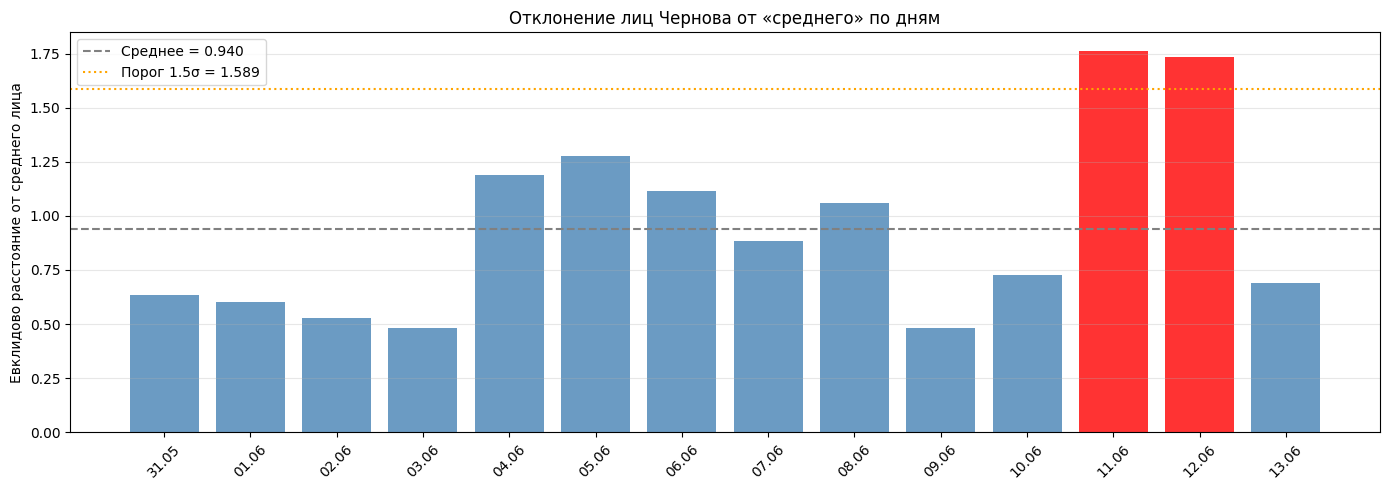

Обнаружены аномалии в следующие дни:
  11.06.2016 : расстояние = 1.760
  12.06.2016 : расстояние = 1.733
Параметры для аномальных дней (нормализованные):

11.06.2016:
  Light Power     : 0.000  (среднее = 0.683)
  Equip Power     : 0.000  (среднее = 0.683)
  Room Temp       : 0.017  (среднее = 0.291)
  Damper Pos      : 1.000  (среднее = 0.499)
  Supply Flow     : 1.000  (среднее = 0.500)
  CO2             : 0.047  (среднее = 0.405)
  Reheat Power    : 1.000  (среднее = 0.178)
  Supply Temp     : 0.972  (среднее = 0.193)
  Outdoor Temp    : 0.929  (среднее = 0.510)

12.06.2016:
  Light Power     : 0.000  (среднее = 0.683)
  Equip Power     : 0.000  (среднее = 0.683)
  Room Temp       : 0.030  (среднее = 0.291)
  Damper Pos      : 0.955  (среднее = 0.499)
  Supply Flow     : 0.955  (среднее = 0.500)
  CO2             : 0.000  (среднее = 0.405)
  Reheat Power    : 0.970  (среднее = 0.178)
  Supply Temp     : 1.000  (среднее = 0.193)
  Outdoor Temp    : 0.888  (среднее = 0.510)


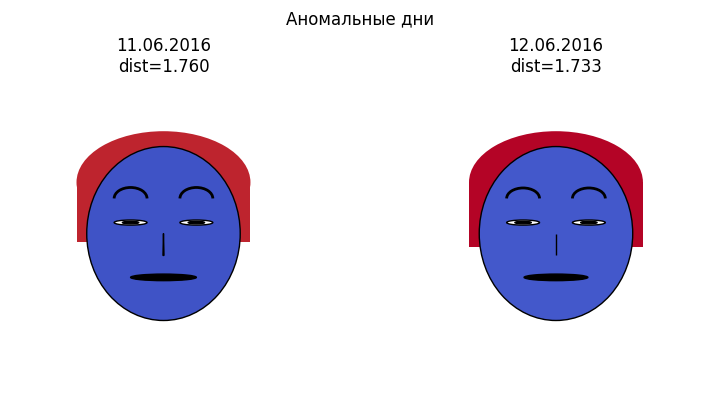

In [19]:
# Список признаков, участвующих в сравнении (порядок важен)
feature_names = ['Light Power', 'Equip Power', 'Room Temp',
                 'Damper Pos', 'Supply Flow', 'CO2',
                 'Reheat Power', 'Supply Temp', 'Outdoor Temp']
# Вычисляем средние нормализованные значения за все дни
mean_vec = daily_norm[feature_names].mean()

print("Средние нормализованные значения (базовое лицо):")
for feat in feature_names:
    print(f"  {feat:15} : {mean_vec[feat]:.3f}")

# Для каждого дня считаем евклидово расстояние до среднего вектора
distances = {}
for day in dates:
    row = daily_norm.loc[day, feature_names]
    dist = np.sqrt(((row - mean_vec)**2).sum())
    distances[day] = dist

dist_series = pd.Series(distances)
mean_dist = dist_series.mean()
std_dist = dist_series.std()
# Порог аномальности: среднее + 1.5 * стандартное отклонение
threshold = mean_dist + 1.5 * std_dist

# Визуализируем расстояния в виде столбчатой диаграммы
plt.figure(figsize=(14, 5))
bar_colors = ['red' if d > threshold else 'steelblue' for d in dist_series.values]
plt.bar(range(n_days), dist_series.values, color=bar_colors, alpha=0.8)
plt.axhline(mean_dist, color='gray', linestyle='--', label=f'Среднее = {mean_dist:.3f}')
plt.axhline(threshold, color='orange', linestyle=':', label=f'Порог 1.5σ = {threshold:.3f}')
plt.xticks(range(n_days), [d.strftime('%d.%m') for d in dates], rotation=45)
plt.ylabel('Евклидово расстояние от среднего лица')
plt.title('Отклонение лиц Чернова от «среднего» по дням')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_distances_var2.png', dpi=150)
plt.show()

# Выявляем дни, превысившие порог
anomaly_days = [d for d in dates if distances[d] > threshold]
print("Обнаружены аномалии в следующие дни:")
for d in anomaly_days:
    print(f"  {d.strftime('%d.%m.%Y')} : расстояние = {distances[d]:.3f}")

# Выводим значения параметров для аномальных дней
if anomaly_days:
    print("Параметры для аномальных дней (нормализованные):")
    for d in anomaly_days:
        row = daily_norm.loc[d, feature_names]
        print(f"\n{d.strftime('%d.%m.%Y')}:")
        for feat in feature_names:
            print(f"  {feat:15} : {row[feat]:.3f}  (среднее = {mean_vec[feat]:.3f})")

    # Рисуем лица только для аномальных дней
    n_anom = len(anomaly_days)
    fig_anom, axes_anom = plt.subplots(1, n_anom, figsize=(4*n_anom, 4))
    if n_anom == 1:
        axes_anom = [axes_anom]
    for i, day in enumerate(anomaly_days):
        row = daily_norm.loc[day, feature_names]
        params = extract_face_params(row)
        draw_chernoff_face(axes_anom[i], params)
        axes_anom[i].set_title(f'{day.strftime("%d.%m.%Y")}\ndist={distances[day]:.3f}')
    plt.suptitle('Аномальные дни')
    plt.tight_layout()
    plt.savefig('anomaly_faces_var2.png', dpi=150)
    plt.show()

## 9. Ответы на вопросы

1) Определите, в какие дни возникали аномальные ситуации в системе тепловентилирования и кондиционирования?

In [20]:
print("1) Аномальные дни:")
for d in anomaly_days:
    print(f"   {d.strftime('%d.%m.%Y')}")

1) Аномальные дни:
   11.06.2016
   12.06.2016


2) Какие параметры связаны с аномалиями?

Аномалии в системе тепловентиляции и кондиционирования связаны со следующими параметрами:
- Light Power (мощность освещения) и Equip Power (мощность оборудования) – близки к нулю, что значительно ниже среднего.
- Damper Pos (положение заслонки VAV) и Supply Flow (расход приточного воздуха) – близки к максимальным значениям (около 1).
- Reheat Power (мощность рекуперации) – также близок к максимуму, что указывает на интенсивный нагрев.
- Supply Temp (температура приточного воздуха) – высокая, около максимальных значений.
- Outdoor Temp (наружная температура) – выше среднего.
- CO2 (концентрация CO2) – очень низкая, близка к нулю.
- Room Temp (температура в помещении) – низкая, значительно ниже среднего.
<br>Эти отклонения наблюдаются 11 и 12 июня 2016 года, что, вероятно, связано с режимом работы системы в выходные дни (отключение оборудования и освещения, усиленный нагрев приточного воздуха при низкой внутренней температуре).